# Metric swings under tract composition placement permutations

Sample a few tract graphs from `white_black.csv`, keep the multiset of tract compositions fixed, shuffle those compositions over the graph nodes, and compare how dissimilarity, Half Edge with `lambda=1`, and Moran's I on tract shares move under those placements.

Dissimilarity does not use graph adjacency, so it should stay fixed under these permutations. Half Edge and Moran use adjacency, so they can swing as the same tract compositions land on different graph positions.

In [2]:
from pathlib import Path
import sys

import gerrychain
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

CSV_RELATIVE_PATHS = [
    Path("../outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_black.csv"),
    Path("outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_black.csv"),
]

for candidate_root in [Path.cwd(), *Path.cwd().parents]:
    csv_path = next(
        (
            (candidate_root / relative_path).resolve()
            for relative_path in CSV_RELATIVE_PATHS
            if (candidate_root / relative_path).exists()
        ),
        None,
    )
    if csv_path is not None:
        break
else:
    raise FileNotFoundError("Could not find white_black.csv from the current notebook directory")

project_root = next(
    parent for parent in csv_path.parents if (parent / "pipeline" / "calculate_metrics.py").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from pipeline import calculate_metrics as metrics

csv_path

PosixPath('/Users/maria/Documents/capy-bara/outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_black.csv')

In [3]:
X_COL = "BLACK"
Y_COL = "WHITE"
TOT_COL = "TOTPOP"

N_AREAS = 12
N_PERMUTATIONS = 500
RANDOM_SEED = 202607

# Keeping the sampled graphs modest makes interactive reruns quick.
MIN_NODES = 25
MAX_NODES = 120

metric_columns = ["dissimilarity", "half_edge_lam_1_angle_1", "moran_share"]
metric_labels = {
    "dissimilarity": "Dissimilarity",
    "half_edge_lam_1_angle_1": "Half Edge, lambda=1",
    "moran_share": "Moran, share",
}

rng = np.random.default_rng(RANDOM_SEED)

## Choose a few graphs

The CSV has one row per study-area graph. This samples a few manageable tract graphs, then loads the graph JSON referenced by each row.

In [4]:
summary = pd.read_csv(csv_path)
summary["year"] = summary["filename"].str.extract(r"study_areas/(\d{4})/").astype(int)
summary["cbsa"] = summary["filename"].str.extract(r"tracts_in_cbsa_(\d+)_")

candidate_rows = summary[
    summary["total_nodes"].between(MIN_NODES, MAX_NODES)
    & (summary["total_edges"] > 0)
    & (summary["total_black"] > 0)
    & (summary["total_white"] > 0)
].copy()

sample_rows = (
    candidate_rows.sample(n=min(N_AREAS, len(candidate_rows)), random_state=RANDOM_SEED)
    .sort_values(["year", "cbsa"])
    .reset_index(drop=True)
)
sample_rows["area_key"] = sample_rows["year"].astype(str) + " CBSA " + sample_rows["cbsa"]

sample_rows[
    [
        "area_key",
        "total_nodes",
        "total_edges",
        "total_black",
        "total_white",
        "dissimilarity",
        "half_edge_lam_1_angle_1",
        "moran",
        "filename",
    ]
]

,area_key,total_nodes,total_edges,total_black,total_white,dissimilarity,half_edge_lam_1_angle_1,moran,filename
0,1980 CBSA 22500,26,58,40793,68176,0.519759,0.577504,0.197411,study_areas/1980/tracts_in_cbsa_22500_1980_mar...
1,1980 CBSA 28740,40,102,6268,145252,0.405505,0.508382,0.176694,study_areas/1980/tracts_in_cbsa_28740_1980_mar...
2,1990 CBSA 11180,27,65,1232,93593,0.502387,0.504699,0.145188,study_areas/1990/tracts_in_cbsa_11180_1990_mar...
3,1990 CBSA 16820,39,95,21219,118275,0.352020,0.522822,0.300752,study_areas/1990/tracts_in_cbsa_16820_1990_mar...
4,2000 CBSA 29200,49,121,3759,165424,0.377184,0.503872,0.251786,study_areas/2000/tracts_in_cbsa_29200_2000_mar...
5,2010 CBSA 34900,40,95,2440,76967,0.652953,0.539690,0.465470,study_areas/2010/tracts_in_cbsa_34900_2010_mar...
6,2020 CBSA 14020,39,97,5095,132364,0.385758,0.507972,0.545111,study_areas/2020/tracts_in_cbsa_14020_2020_mar...
7,2020 CBSA 16620,81,203,13706,227211,0.563049,0.537168,0.462488,study_areas/2020/tracts_in_cbsa_16620_2020_mar...
8,2020 CBSA 24300,33,83,1020,120749,0.258292,0.500921,0.252489,study_areas/2020/tracts_in_cbsa_24300_2020_mar...
9,2020 CBSA 41660,28,67,4019,64369,0.319569,0.505710,0.078713,study_areas/2020/tracts_in_cbsa_41660_2020_mar...


## Permute composition placements

Each permutation preserves the exact list of `(BLACK, WHITE, TOTPOP)` node values. Only the graph node receiving each tuple changes.

In [5]:
def metric_values(graph):
    for cached_function in (metrics._angle_1, metrics._angle_2, metrics.property_sum):
        cached_function.cache_clear()

    return {
        "dissimilarity": metrics.dissimilarity(graph, X_COL, Y_COL),
        "half_edge_lam_1_angle_1": metrics.half_edge(
            graph, X_COL, Y_COL, lam=1, func=metrics.angle_1
        ),
        "moran_share": metrics.moran(graph, X_COL, Y_COL),
    }

In [6]:
records = []
composition_columns = [X_COL, Y_COL, TOT_COL]

for area in sample_rows.itertuples(index=False):
    graph_path = project_root / area.filename
    graph = gerrychain.Graph.from_json(graph_path)
    node_order = list(graph.nodes())
    compositions = [
        {column: int(graph.nodes[node][column]) for column in composition_columns}
        for node in node_order
    ]

    records.append(
        {
            "area_key": area.area_key,
            "year": area.year,
            "cbsa": area.cbsa,
            "filename": area.filename,
            "placement": "observed",
            "permutation": -1,
            "is_observed": True,
            **metric_values(graph),
        }
    )

    for permutation in range(N_PERMUTATIONS):
        permuted_graph = graph.copy()
        shuffled_indices = rng.permutation(len(node_order))

        for node, composition_index in zip(node_order, shuffled_indices):
            for column, value in compositions[composition_index].items():
                permuted_graph.nodes[node][column] = value

        records.append(
            {
                "area_key": area.area_key,
                "year": area.year,
                "cbsa": area.cbsa,
                "filename": area.filename,
                "placement": "permuted",
                "permutation": permutation,
                "is_observed": False,
                **metric_values(permuted_graph),
            }
        )

results = pd.DataFrame(records)
results.shape

(6012, 10)

In [7]:
observed_check = results[results["is_observed"]].merge(
    sample_rows[
        ["area_key", "dissimilarity", "half_edge_lam_1_angle_1", "moran"]
    ].rename(columns={"moran": "moran_from_csv"}),
    on="area_key",
    suffixes=("_recomputed", "_from_csv"),
)

# observed_check[
#     [
#         "area_key",
#         "dissimilarity_recomputed",
#         "dissimilarity_from_csv",
#         "half_edge_lam_1_angle_1_recomputed",
#         "half_edge_lam_1_angle_1_from_csv",
#         "moran_share",
#         "moran_from_csv",
#     ]
# ]

In [8]:
results[
    ["area_key", "placement", "permutation", "dissimilarity", "half_edge_lam_1_angle_1", "moran_share"]
].head(20)

,area_key,placement,permutation,dissimilarity,half_edge_lam_1_angle_1,moran_share
0,1980 CBSA 22500,observed,-1,0.519759,0.577504,0.197411
1,1980 CBSA 22500,permuted,0,0.519759,0.509165,-0.194073
2,1980 CBSA 22500,permuted,1,0.519759,0.533533,-0.097889
3,1980 CBSA 22500,permuted,2,0.519759,0.534019,-0.016143
4,1980 CBSA 22500,permuted,3,0.519759,0.493877,-0.255362
5,1980 CBSA 22500,permuted,4,0.519759,0.586656,0.251615
6,1980 CBSA 22500,permuted,5,0.519759,0.507909,-0.208867
7,1980 CBSA 22500,permuted,6,0.519759,0.535027,-0.045177
8,1980 CBSA 22500,permuted,7,0.519759,0.510362,-0.208483
9,1980 CBSA 22500,permuted,8,0.519759,0.520266,-0.143952


## Normalize by permutation standard deviation

`sd_from_observed` is `(permuted value - observed value) / permutation standard deviation`, computed separately for each area and metric. This is useful for asking whether the observed placement is unusual under that metric's own permutation null. Metrics with no permutation spread, such as dissimilarity here, are assigned a normalized swing of `0`.

For asking which metric swings more in an absolute sense, use the later `std / observable range` table and plot.

In [9]:
long_results = results.melt(
    id_vars=["area_key", "year", "cbsa", "filename", "placement", "permutation", "is_observed"],
    value_vars=metric_columns,
    var_name="metric",
    value_name="value",
)
long_results["metric_label"] = long_results["metric"].map(metric_labels)

permutation_stats = (
    long_results[~long_results["is_observed"]]
    .groupby(["area_key", "metric"], as_index=False)["value"]
    .agg(permutation_mean="mean", permutation_sd="std", permutation_min="min", permutation_max="max")
)
observed_values = long_results[long_results["is_observed"]][
    ["area_key", "metric", "value"]
].rename(columns={"value": "observed_value"})

long_results = long_results.merge(permutation_stats, on=["area_key", "metric"])
long_results = long_results.merge(observed_values, on=["area_key", "metric"])

has_spread = long_results["permutation_sd"] > 1e-12
long_results["z_score"] = np.where(
    has_spread,
    (long_results["value"] - long_results["permutation_mean"]) / long_results["permutation_sd"],
    0.0,
)
long_results["sd_from_observed"] = np.where(
    has_spread,
    (long_results["value"] - long_results["observed_value"]) / long_results["permutation_sd"],
    0.0,
)

long_results.head()

,area_key,year,cbsa,filename,placement,permutation,is_observed,metric,value,metric_label,permutation_mean,permutation_sd,permutation_min,permutation_max,observed_value,z_score,sd_from_observed
0,1980 CBSA 22500,1980,22500,study_areas/1980/tracts_in_cbsa_22500_1980_mar...,observed,-1,True,dissimilarity,0.519759,Dissimilarity,0.519759,0.0,0.519759,0.519759,0.519759,0.0,0.0
1,1980 CBSA 22500,1980,22500,study_areas/1980/tracts_in_cbsa_22500_1980_mar...,permuted,0,False,dissimilarity,0.519759,Dissimilarity,0.519759,0.0,0.519759,0.519759,0.519759,0.0,0.0
2,1980 CBSA 22500,1980,22500,study_areas/1980/tracts_in_cbsa_22500_1980_mar...,permuted,1,False,dissimilarity,0.519759,Dissimilarity,0.519759,0.0,0.519759,0.519759,0.519759,0.0,0.0
3,1980 CBSA 22500,1980,22500,study_areas/1980/tracts_in_cbsa_22500_1980_mar...,permuted,2,False,dissimilarity,0.519759,Dissimilarity,0.519759,0.0,0.519759,0.519759,0.519759,0.0,0.0
4,1980 CBSA 22500,1980,22500,study_areas/1980/tracts_in_cbsa_22500_1980_mar...,permuted,3,False,dissimilarity,0.519759,Dissimilarity,0.519759,0.0,0.519759,0.519759,0.519759,0.0,0.0


In [10]:
spread_table = (
    long_results[~long_results["is_observed"]]
    .groupby(["area_key", "metric", "metric_label"], as_index=False)
    .agg(
        observed_value=("observed_value", "first"),
        permutation_mean=("permutation_mean", "first"),
        permutation_sd=("permutation_sd", "first"),
        permutation_min=("permutation_min", "first"),
        permutation_max=("permutation_max", "first"),
        normalized_min=("sd_from_observed", "min"),
        normalized_max=("sd_from_observed", "max"),
    )
)

spread_table["observed_percentile_vs_permutations"] = spread_table.apply(
    lambda row: (
        long_results[
            (long_results["area_key"] == row["area_key"])
            & (long_results["metric"] == row["metric"])
            & (~long_results["is_observed"])
            & (long_results["value"] <= row["observed_value"])
        ].shape[0]
        / N_PERMUTATIONS
    ),
    axis=1,
)

spread_table.sort_values(["area_key", "metric"])

,area_key,metric,metric_label,observed_value,permutation_mean,permutation_sd,permutation_min,permutation_max,normalized_min,normalized_max,observed_percentile_vs_permutations
0,1980 CBSA 22500,dissimilarity,Dissimilarity,0.519759,0.519759,0.000000,0.519759,0.519759,0.000000,0.000000,1.000
1,1980 CBSA 22500,half_edge_lam_1_angle_1,"Half Edge, lambda=1",0.577504,0.530131,0.018725,0.483686,0.588048,-5.010216,0.563041,0.988
2,1980 CBSA 22500,moran_share,"Moran, share",0.197411,-0.043436,0.111085,-0.321737,0.351397,-4.673425,1.386201,0.978
3,1980 CBSA 28740,dissimilarity,Dissimilarity,0.405505,0.405505,0.000000,0.405505,0.405505,0.000000,0.000000,1.000
4,1980 CBSA 28740,half_edge_lam_1_angle_1,"Half Edge, lambda=1",0.508382,0.504702,0.002227,0.499419,0.513180,-4.023945,2.153975,0.934
5,1980 CBSA 28740,moran_share,"Moran, share",0.176694,-0.024873,0.071160,-0.226641,0.211078,-5.667959,0.483198,0.990
6,1990 CBSA 11180,dissimilarity,Dissimilarity,0.502387,0.502387,0.000000,0.502387,0.502387,0.000000,0.000000,1.000
7,1990 CBSA 11180,half_edge_lam_1_angle_1,"Half Edge, lambda=1",0.504699,0.501469,0.000978,0.498872,0.505015,-5.956797,0.322148,0.996
8,1990 CBSA 11180,moran_share,"Moran, share",0.145188,-0.037161,0.089164,-0.307065,0.300220,-5.072154,1.738738,0.958
9,1990 CBSA 16820,dissimilarity,Dissimilarity,0.352020,0.352020,0.000000,0.352020,0.352020,0.000000,0.000000,1.000


## Spread comparison

Compares raw permutation standard deviations after dividing by each metric's observable range: `1` for Dissimilarity and Half Edge, `2` for Moran's I. This keeps absolute swing comparable without standardizing away the spread itself.

In [11]:
observable_ranges = {
    "dissimilarity": 1.0,
    "half_edge_lam_1_angle_1": 1.0,
    "moran_share": 2.0,
}

tyapa_style_spread = spread_table.copy()
tyapa_style_spread["observable_range"] = tyapa_style_spread["metric"].map(observable_ranges)
tyapa_style_spread["std_over_observable_range"] = (
    tyapa_style_spread["permutation_sd"] / tyapa_style_spread["observable_range"]
)
tyapa_style_spread["range_over_observable_range"] = (
    (tyapa_style_spread["permutation_max"] - tyapa_style_spread["permutation_min"])
    / tyapa_style_spread["observable_range"]
)

tyapa_style_spread.sort_values(["area_key", "metric"])[
    [
        "area_key",
        "metric_label",
        "permutation_sd",
        "observable_range",
        "std_over_observable_range",
        "range_over_observable_range",
    ]
]

,area_key,metric_label,permutation_sd,observable_range,std_over_observable_range,range_over_observable_range
0,1980 CBSA 22500,Dissimilarity,0.000000,1.0,0.000000,0.000000
1,1980 CBSA 22500,"Half Edge, lambda=1",0.018725,1.0,0.018725,0.104361
2,1980 CBSA 22500,"Moran, share",0.111085,2.0,0.055543,0.336567
3,1980 CBSA 28740,Dissimilarity,0.000000,1.0,0.000000,0.000000
4,1980 CBSA 28740,"Half Edge, lambda=1",0.002227,1.0,0.002227,0.013761
5,1980 CBSA 28740,"Moran, share",0.071160,2.0,0.035580,0.218860
6,1990 CBSA 11180,Dissimilarity,0.000000,1.0,0.000000,0.000000
7,1990 CBSA 11180,"Half Edge, lambda=1",0.000978,1.0,0.000978,0.006143
8,1990 CBSA 11180,"Moran, share",0.089164,2.0,0.044582,0.303643
9,1990 CBSA 16820,Dissimilarity,0.000000,1.0,0.000000,0.000000


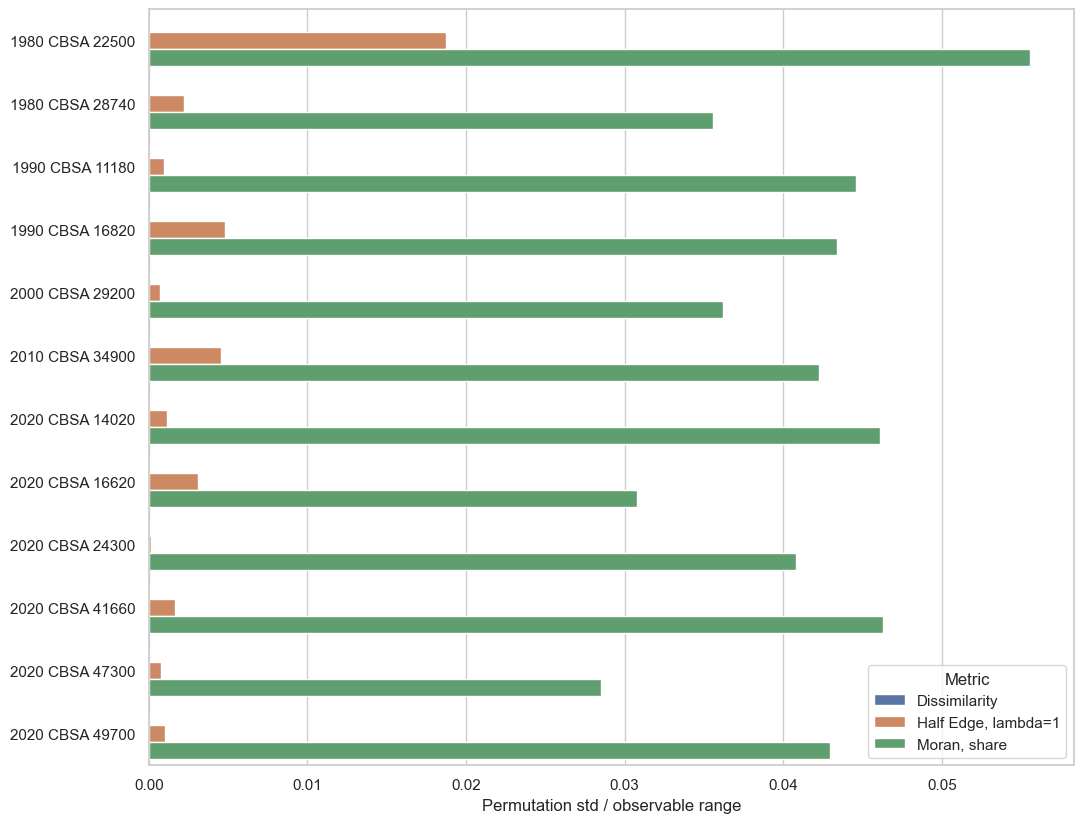

In [12]:
area_order = sample_rows["area_key"].tolist()

plt.figure(figsize=(11, max(4, 0.7 * len(area_order))))
sns.barplot(
    data=tyapa_style_spread,
    x="std_over_observable_range",
    y="area_key",
    hue="metric_label",
    order=area_order,
)
plt.xlabel("Permutation std / observable range")
plt.ylabel("")
plt.legend(title="Metric", loc="best")
plt.tight_layout()

## Raw metric distributions

The vertical line is the observed graph placement. Raw values are split by metric because the scales differ.

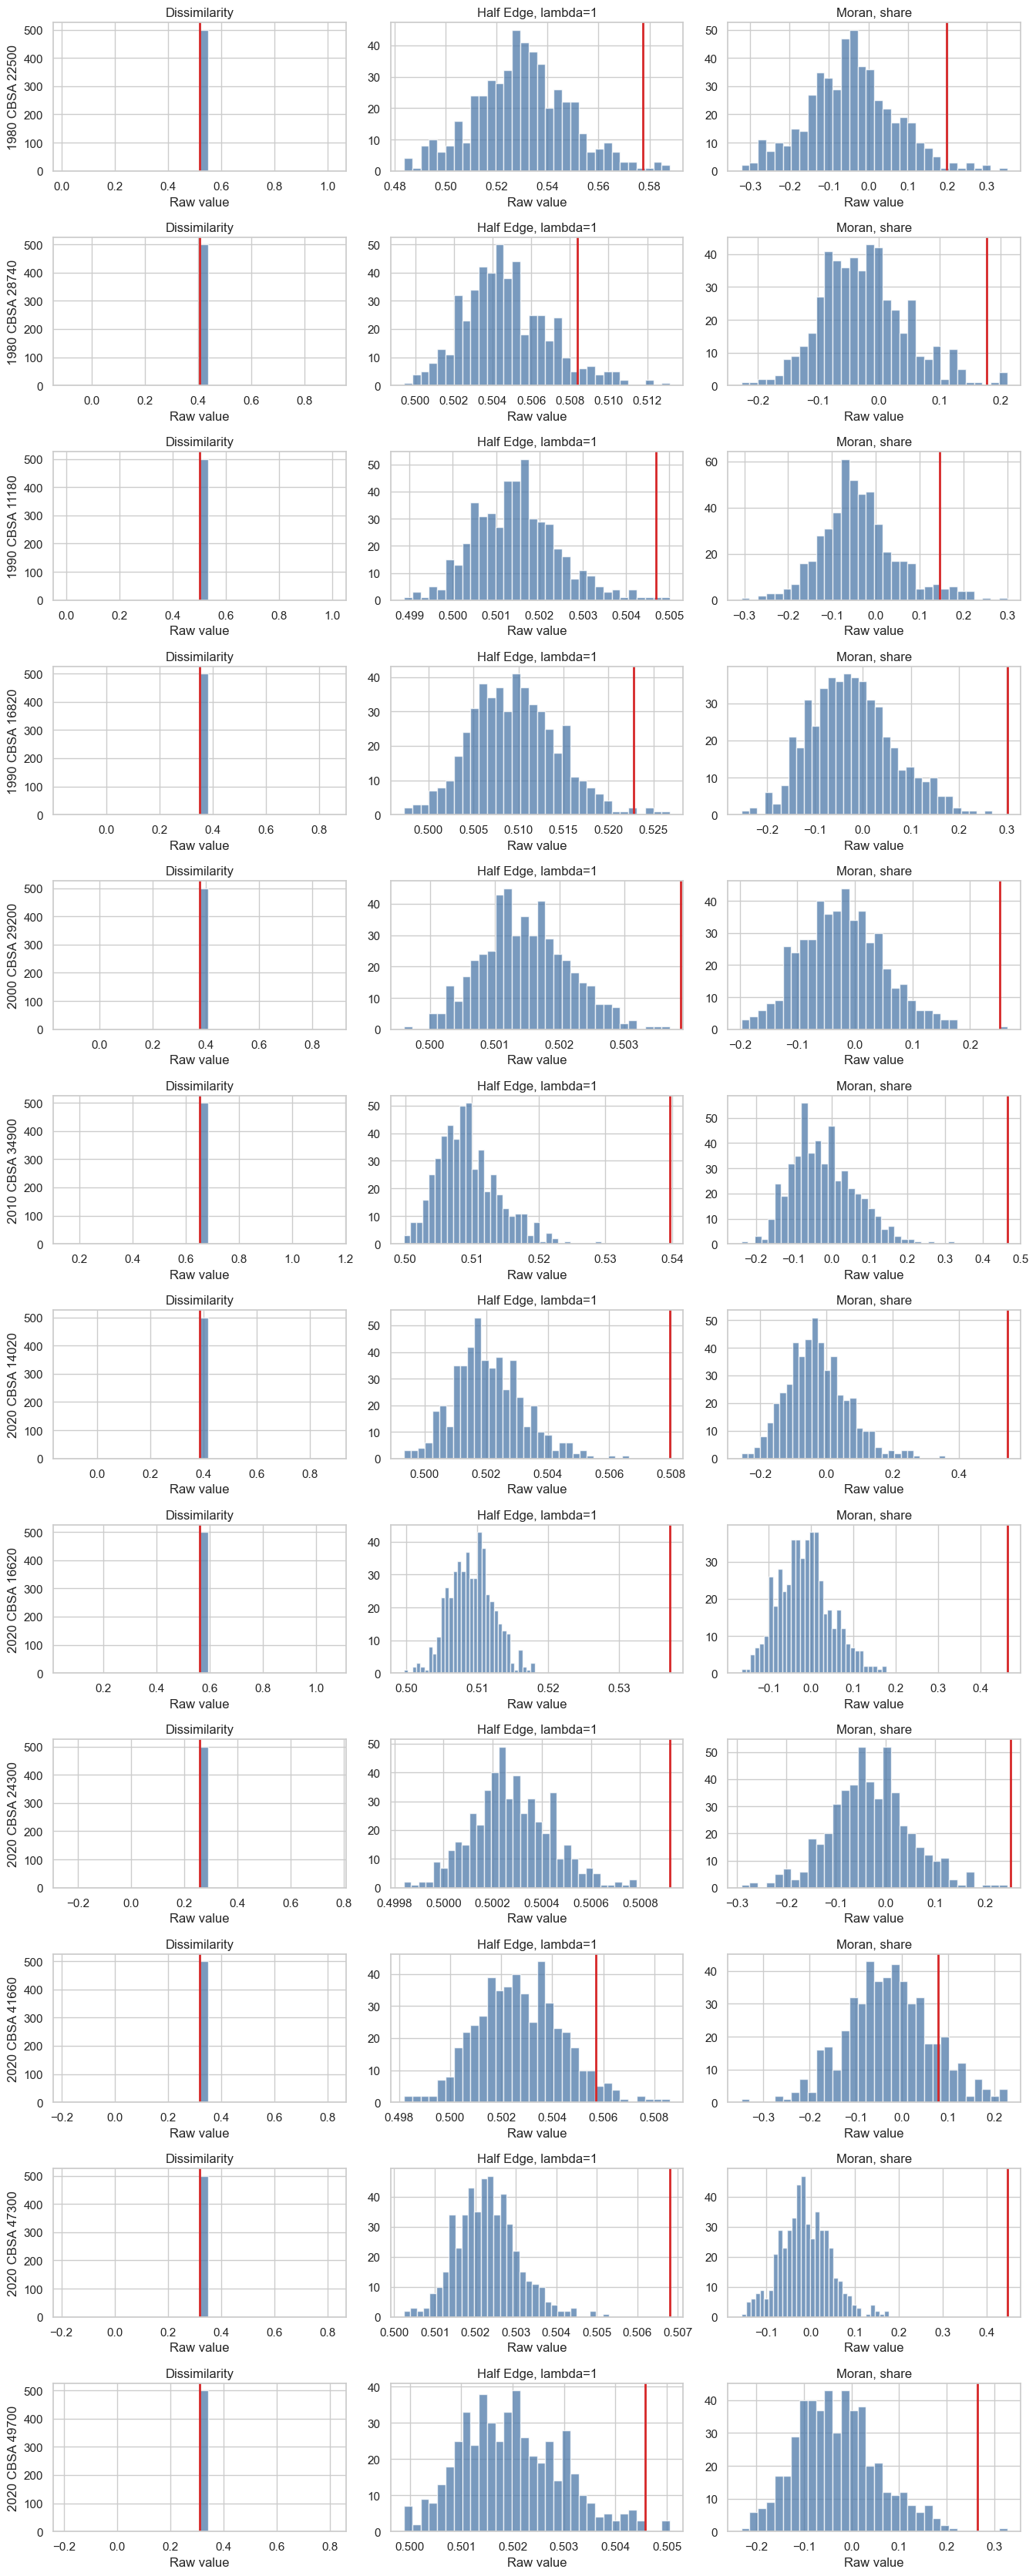

In [22]:
area_order = sample_rows["area_key"].tolist()
fig, axes = plt.subplots(
    len(area_order),
    len(metric_columns),
    figsize=(4.5 * len(metric_columns), 2.8 * len(area_order)),
    squeeze=False,
)

for row_index, area_key in enumerate(area_order):
    for column_index, metric in enumerate(metric_columns):
        ax = axes[row_index, column_index]
        subset = long_results[
            (long_results["area_key"] == area_key)
            & (long_results["metric"] == metric)
            & (~long_results["is_observed"])
        ]
        observed_value = subset["observed_value"].iloc[0]

        ax.hist(subset["value"], bins=32, color="#4C78A8", alpha=0.75)
        ax.axvline(observed_value, color="#D62728", linewidth=2)
        ax.set_title(metric_labels[metric])
        ax.set_xlabel("Raw value")
        ax.set_ylabel(area_key if column_index == 0 else "")

fig.tight_layout()

## Standard-deviation normalized swing

This view uses the same x-axis for all three metrics. Zero is the observed placement; values show how many permutation standard deviations a shuffled placement lands away from it.

/Users/maria/Library/Caches/pypoetry/virtualenvs/capy-NsKqgI8c-py3.13/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Users/maria/Library/Caches/pypoetry/virtualenvs/capy-NsKqgI8c-py3.13/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Users/maria/Library/Caches/pypoetry/virtualenvs/capy-NsKqgI8c-py3.13/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


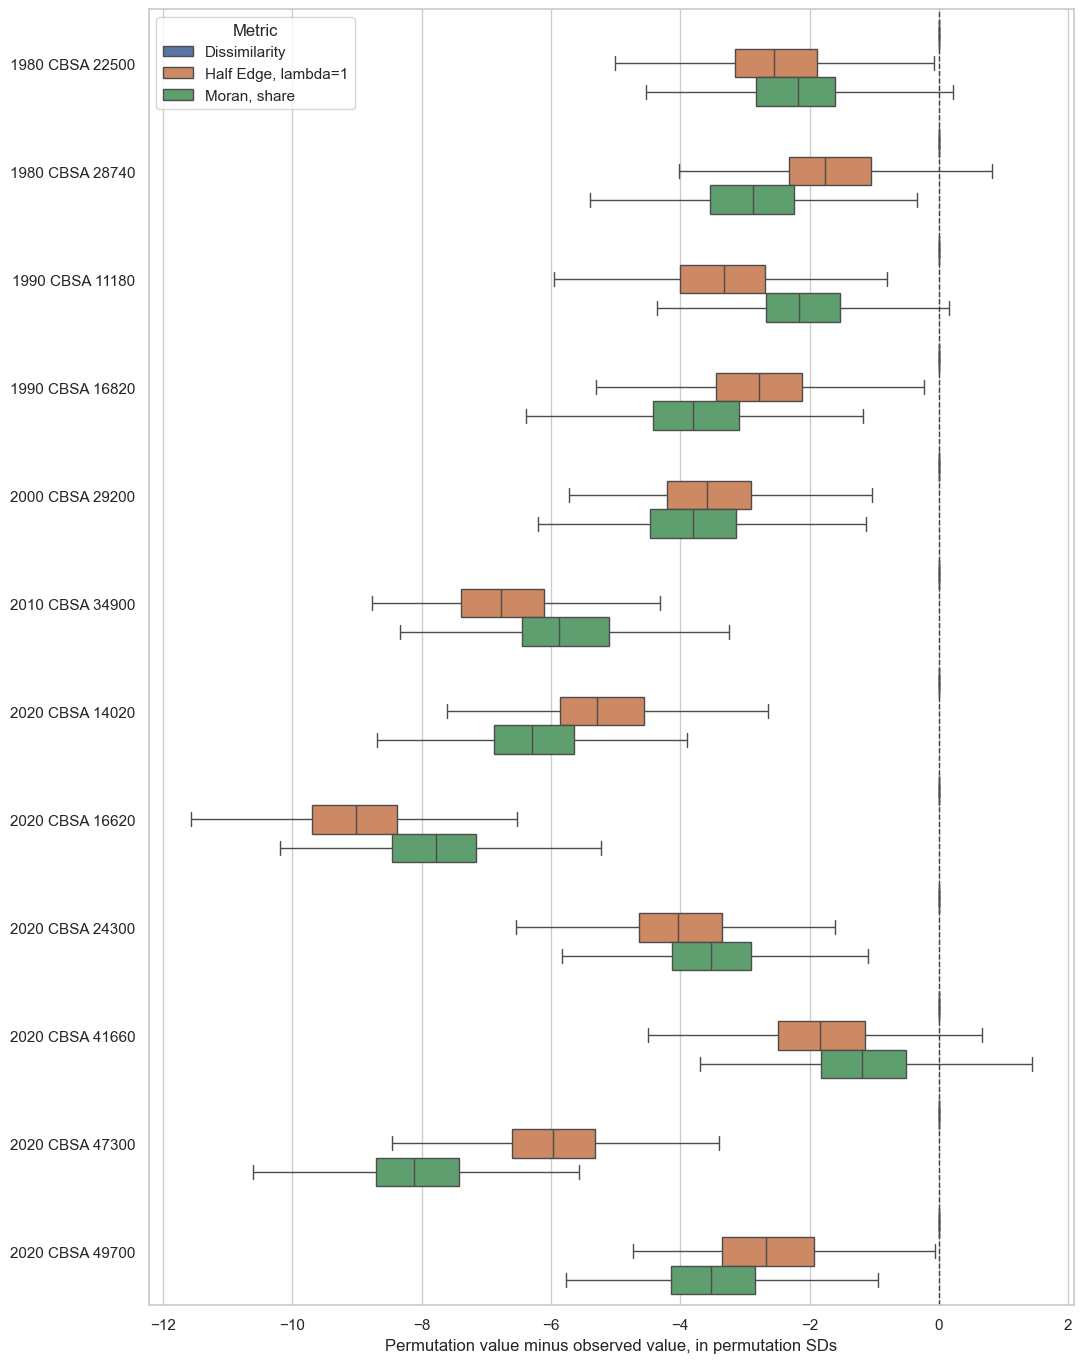

In [23]:
plt.figure(figsize=(11, max(4, 1.15 * len(area_order))))
sns.boxplot(
    data=long_results[~long_results["is_observed"]],
    x="sd_from_observed",
    y="area_key",
    hue="metric_label",
    order=area_order,
    showfliers=False,
)
plt.axvline(0, color="0.25", linestyle="--", linewidth=1)
plt.xlabel("Permutation value minus observed value, in permutation SDs")
plt.ylabel("")
plt.legend(title="Metric", loc="best")
plt.tight_layout()

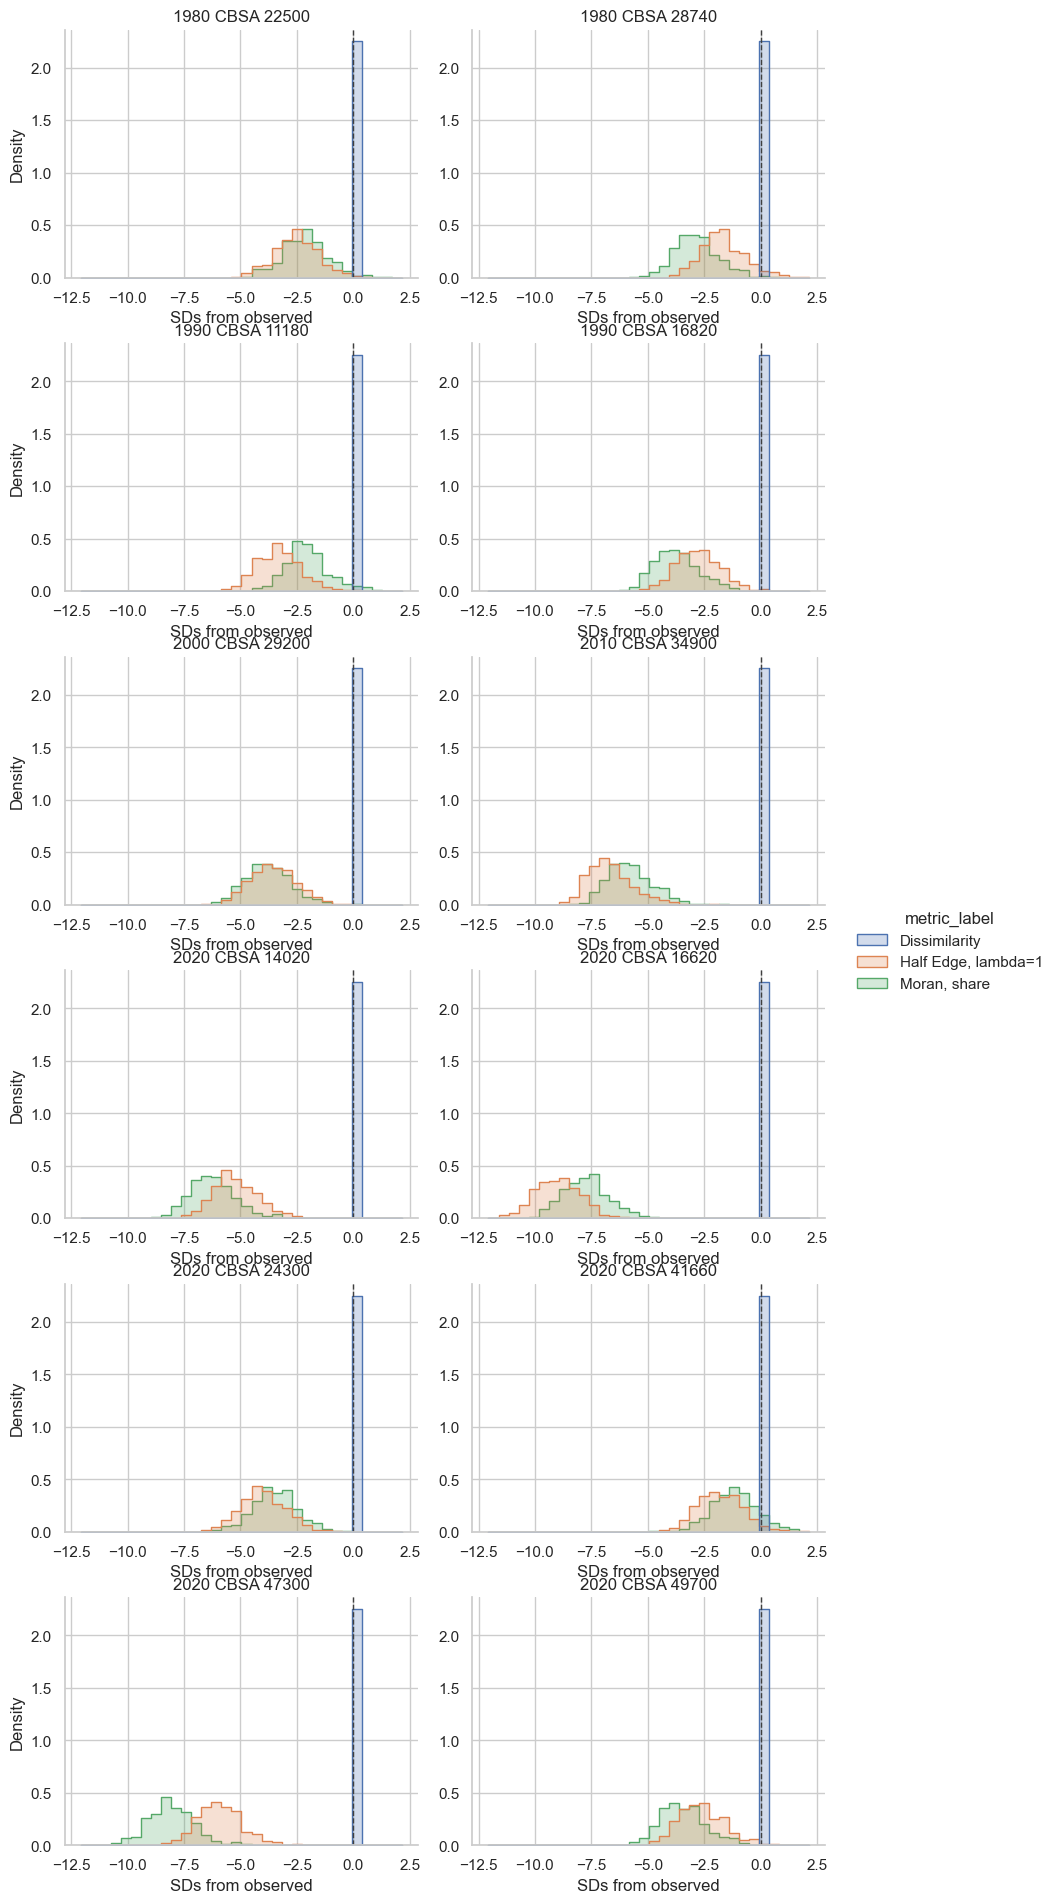

In [24]:
g = sns.displot(
    data=long_results[~long_results["is_observed"]],
    x="sd_from_observed",
    hue="metric_label",
    col="area_key",
    col_wrap=2,
    kind="hist",
    bins=32,
    element="step",
    stat="density",
    common_norm=False,
    facet_kws={"sharex": False, "sharey": False},
    height=3.2,
    aspect=1.35,
)
for ax in g.axes.flat:
    ax.axvline(0, color="0.25", linestyle="--", linewidth=1)
    ax.set_xlabel("SDs from observed")
g.set_titles("{col_name}")